## ML Classifier: IoT Network Traffic Classification
### CIC-BCCC-NRC TabularIoTAttack-2024 — Random Forest & XGBoost

This notebook trains and evaluates conventional ML classifiers (Random Forest and XGBoost) on the combined IoT attack dataset. It serves as the **Track B** baseline for our LLM-augmented comparison.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight

import xgboost as xgb
import shap

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 6)
RANDOM_STATE = 43          # seed from referenced paper
os.makedirs("models", exist_ok=True)

print("All imports OK")

All imports OK


/Users/sriram/Desktop/PROJECTS/CSE534_Final_Project/llm_ddos/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data Loading

Load all four traffic classes. DoS TCP Flood is capped at 100,000 rows to match the EDA (the full file is ~1 GB with ~600k+ rows that would skew training time without adding class diversity).

In [2]:
benign   = pd.read_csv("data/Benign Traffic.csv")
ddos     = pd.read_csv("data/DDoS UDP Flood.csv")
dos_tcp  = pd.read_csv("data/DoS TCP Flood.csv", nrows=100_000)
recon    = pd.read_csv("data/Recon Port Scan.csv")

benign["Label"]  = "BENIGN"
ddos["Label"]    = "DDOS_UDP"
dos_tcp["Label"] = "DOS_TCP"
recon["Label"]   = "RECON"

df = pd.concat([benign, ddos, dos_tcp, recon], ignore_index=True)
print(f"Combined shape: {df.shape}")
print(df["Label"].value_counts())

Combined shape: (620718, 85)
Label
RECON       485522
DOS_TCP     100000
BENIGN       32620
DDOS_UDP      2576
Name: count, dtype: int64


## 2. Data Cleaning

Drop pure identifier columns (Src IP, Dst IP, Timestamp, Attack Name). **Keep `Flow ID`** — it is used as a grouping key for the flow-disjoint split and excluded from the feature matrix afterwards.

In [3]:
# Keep Flow ID — needed for group-based split; drop everything else that's non-analytical
DROP_COLS = ["Src IP", "Dst IP", "Timestamp", "Attack Name"]
df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)

# Sanity checks on numeric columns
num_cols = df.select_dtypes("number").columns
missing  = df[num_cols].isnull().sum().sum()
inf_vals = np.isinf(df[num_cols]).sum().sum()
print(f"Missing values : {missing}")
print(f"Infinite values: {inf_vals}")
print(f"Remaining columns: {df.shape[1]}  (Flow ID + features + Label)")

# Report Flow ID duplication (data-leakage audit)
total_rows  = len(df)
unique_fids = df["Flow ID"].nunique()
dup_rows    = total_rows - unique_fids
print(f"\nFlow ID audit:")
print(f"  Total rows       : {total_rows:,}")
print(f"  Unique Flow IDs  : {unique_fids:,}")
print(f"  Rows sharing IDs : {dup_rows:,}  ({dup_rows/total_rows*100:.2f}%)")
cross = df.groupby("Flow ID")["Label"].nunique()
cross_class_ids = (cross > 1).sum()
print(f"  Cross-class IDs  : {cross_class_ids}  (same 5-tuple appears in 2+ classes)")

Missing values : 0
Infinite values: 0
Remaining columns: 81  (Flow ID + features + Label)

Flow ID audit:
  Total rows       : 620,718
  Unique Flow IDs  : 589,429
  Rows sharing IDs : 31,289  (5.04%)
  Cross-class IDs  : 36  (same 5-tuple appears in 2+ classes)


## 3. Feature & Label Setup

Separate features (`X`), target (`y`), and flow groups (`groups`) used for the disjoint split. `Flow ID` is extracted as the grouping key and excluded from the feature matrix.

In [4]:
groups       = df["Flow ID"].values                        # grouping key — NOT a feature
feature_cols = [c for c in df.columns if c not in ("Label", "Flow ID")]
X            = df[feature_cols].values
y_raw        = df["Label"].values

le = LabelEncoder()
y  = le.fit_transform(y_raw)
CLASS_NAMES = list(le.classes_)

print("Classes:", dict(enumerate(CLASS_NAMES)))
print(f"X shape: {X.shape}   ({len(feature_cols)} features, {len(y):,} samples)")

unique, counts = np.unique(y, return_counts=True)
for cls, cnt in zip(CLASS_NAMES, counts):
    print(f"  {cls}: {cnt:>7,}  ({cnt/len(y)*100:.1f}%)")

Classes: {0: 'BENIGN', 1: 'DDOS_UDP', 2: 'DOS_TCP', 3: 'RECON'}
X shape: (620718, 79)   (79 features, 620,718 samples)
  BENIGN:  32,620  (5.3%)
  DDOS_UDP:   2,576  (0.4%)
  DOS_TCP: 100,000  (16.1%)
  RECON: 485,522  (78.2%)


## 4. Flow-Disjoint Train / Test Split

Following the referenced paper's methodology (Debunk Traffic Representation):

- **Test size ≈ 25%** — using `StratifiedGroupKFold(n_splits=4)` which gives 1/4 ≈ 25% per fold
- **Flow-disjoint**: all rows sharing the same `Flow ID` (5-tuple) go entirely to train **or** test — never split across both. This prevents the 5% of duplicate Flow IDs and 36 cross-class IDs from leaking between splits.
- **Stratified by class** — each class maintains proportional representation in both sets
- **Seed 43** — matching the referenced paper

In [5]:
sgkf = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)

# Take the first fold's test indices as our held-out test set (≈25%)
train_idx, test_idx = next(sgkf.split(X, y, groups=groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"Train: {len(train_idx):,}  ({len(train_idx)/len(y)*100:.1f}%)")
print(f"Test : {len(test_idx):,}  ({len(test_idx)/len(y)*100:.1f}%)")
print("\nTest class distribution:")
for cls, cnt in zip(CLASS_NAMES, np.bincount(y_test)):
    print(f"  {cls}: {cnt:>7,}  ({cnt/len(y_test)*100:.1f}%)")

# Verify flow disjointness
train_flows = set(groups[train_idx])
test_flows  = set(groups[test_idx])
overlap     = train_flows & test_flows
print(f"\nFlow ID overlap between train and test: {len(overlap)}  (must be 0)")

Train: 465,538  (75.0%)
Test : 155,180  (25.0%)

Test class distribution:
  BENIGN:   8,155  (5.3%)
  DDOS_UDP:     644  (0.4%)
  DOS_TCP:  25,000  (16.1%)
  RECON: 121,381  (78.2%)

Flow ID overlap between train and test: 0  (must be 0)


## 5. Log Normalization

Following the referenced paper, apply `log(1 + |x|) × sign(x)` to all features. This compresses heavy-tailed CICFlowMeter distributions (packet rates, byte counts) and is applied identically to train and test so there is no leakage. The signed form handles rare negative sentinel values (e.g. `FWD Init Win Bytes = −1` for non-TCP flows).

In [6]:
def log_normalize(arr: np.ndarray) -> np.ndarray:
    return np.sign(arr) * np.log1p(np.abs(arr))

X_train = log_normalize(X_train)
X_test  = log_normalize(X_test)

print(f"X_train range after log-norm: [{X_train.min():.3f}, {X_train.max():.3f}]")
print(f"X_test  range after log-norm: [{X_test.min():.3f},  {X_test.max():.3f}]")

X_train range after log-norm: [-16.366, 21.546]
X_test  range after log-norm: [-16.367,  18.603]


## 6. Random Forest

`class_weight='balanced'` up-weights minority classes inversely to their frequency — no manual SMOTE needed for tree-based methods.

In [7]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

print("Training Random Forest …")
rf.fit(X_train, y_train)
print("Done.")

y_pred_rf = rf.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_f1  = f1_score(y_test, y_pred_rf, average="macro")
print(f"\nRandom Forest — Accuracy: {rf_acc:.4f}  |  Macro-F1: {rf_f1:.4f}")
print("\nPer-class Report:")
print(classification_report(y_test, y_pred_rf, target_names=CLASS_NAMES, digits=4))

Training Random Forest …
Done.

Random Forest — Accuracy: 0.9889  |  Macro-F1: 0.7942

Per-class Report:
              precision    recall  f1-score   support

      BENIGN     0.9409    0.8456    0.8907      8155
    DDOS_UDP     0.2007    0.5031    0.2870       644
     DOS_TCP     1.0000    0.9994    0.9997     25000
       RECON     1.0000    0.9989    0.9994    121381

    accuracy                         0.9889    155180
   macro avg     0.7854    0.8368    0.7942    155180
weighted avg     0.9936    0.9889    0.9908    155180



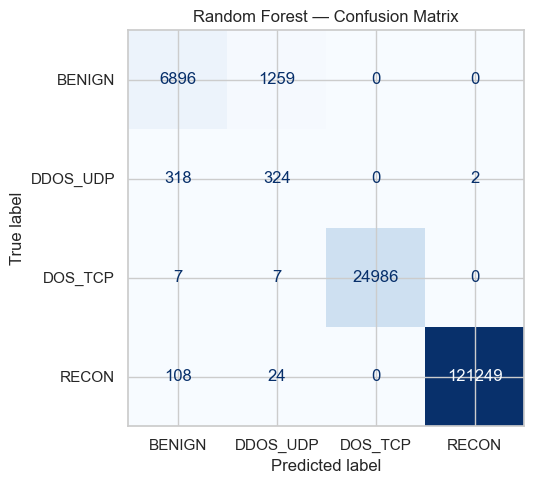

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp  = ConfusionMatrixDisplay(cm_rf, display_labels=CLASS_NAMES)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Random Forest — Confusion Matrix")
plt.tight_layout()
plt.savefig("models/rf_confusion_matrix.png", dpi=150)
plt.show()

## 7. XGBoost

XGBoost's multi-class objective doesn't expose `class_weight` directly, so per-sample weights from inverse class frequencies are passed to `fit(sample_weight=…)`.

In [9]:
class_weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
sample_weights = class_weights[y_train]   # map each sample to its class weight

xgb_clf = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=len(CLASS_NAMES),
    eval_metric="mlogloss",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbosity=0,
)

print("Training XGBoost …")
xgb_clf.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_test, y_test)],
    verbose=False,
)
print("Done.")

y_pred_xgb = xgb_clf.predict(X_test)

xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_f1  = f1_score(y_test, y_pred_xgb, average="macro")
print(f"\nXGBoost — Accuracy: {xgb_acc:.4f}  |  Macro-F1: {xgb_f1:.4f}")
print("\nPer-class Report:")
print(classification_report(y_test, y_pred_xgb, target_names=CLASS_NAMES, digits=4))

Training XGBoost …
Done.

XGBoost — Accuracy: 0.9771  |  Macro-F1: 0.7339

Per-class Report:
              precision    recall  f1-score   support

      BENIGN     0.9447    0.6076    0.7396      8155
    DDOS_UDP     0.1155    0.6599    0.1965       644
     DOS_TCP     1.0000    0.9998    0.9999     25000
       RECON     1.0000    0.9990    0.9995    121381

    accuracy                         0.9771    155180
   macro avg     0.7650    0.8166    0.7339    155180
weighted avg     0.9934    0.9771    0.9825    155180



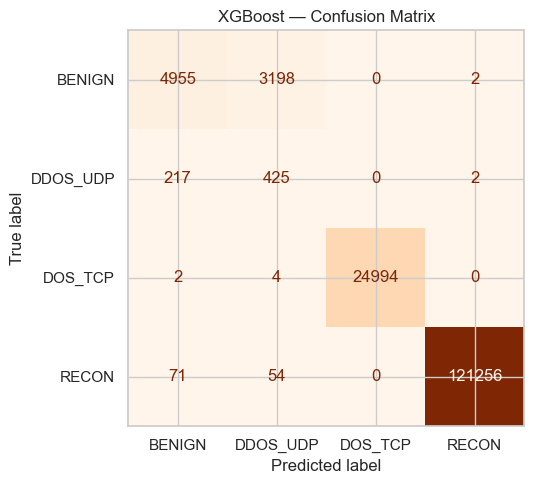

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp   = ConfusionMatrixDisplay(cm_xgb, display_labels=CLASS_NAMES)
disp.plot(ax=ax, colorbar=False, cmap="Oranges")
ax.set_title("XGBoost — Confusion Matrix")
plt.tight_layout()
plt.savefig("models/xgb_confusion_matrix.png", dpi=150)
plt.show()

## 8. Side-by-Side Comparison

Consolidate accuracy, macro-F1, and per-class F1 into a single summary table and bar chart.

In [11]:
def extract_f1(y_true, y_pred, names):
    report = classification_report(y_true, y_pred, target_names=names, output_dict=True)
    return {cls: report[cls]["f1-score"] for cls in names}

rf_per_f1  = extract_f1(y_test, y_pred_rf,  CLASS_NAMES)
xgb_per_f1 = extract_f1(y_test, y_pred_xgb, CLASS_NAMES)

comparison = pd.DataFrame({
    "Class":      CLASS_NAMES,
    "RF F1":      [rf_per_f1[c]  for c in CLASS_NAMES],
    "XGBoost F1": [xgb_per_f1[c] for c in CLASS_NAMES],
})
comparison.loc[len(comparison)] = ["Macro avg", rf_f1,  xgb_f1]
comparison.loc[len(comparison)] = ["Accuracy",  rf_acc, xgb_acc]
comparison = comparison.set_index("Class")
print(comparison.round(4).to_string())
comparison

            RF F1  XGBoost F1
Class                        
BENIGN     0.8907      0.7396
DDOS_UDP   0.2870      0.1965
DOS_TCP    0.9997      0.9999
RECON      0.9994      0.9995
Macro avg  0.7942      0.7339
Accuracy   0.9889      0.9771


,RF F1,XGBoost F1
Class,,
BENIGN,0.890726,0.739552
DDOS_UDP,0.286980,0.196532
DOS_TCP,0.999720,0.999880
RECON,0.999448,0.999468
Macro avg,0.794218,0.733858
Accuracy,0.988884,0.977123


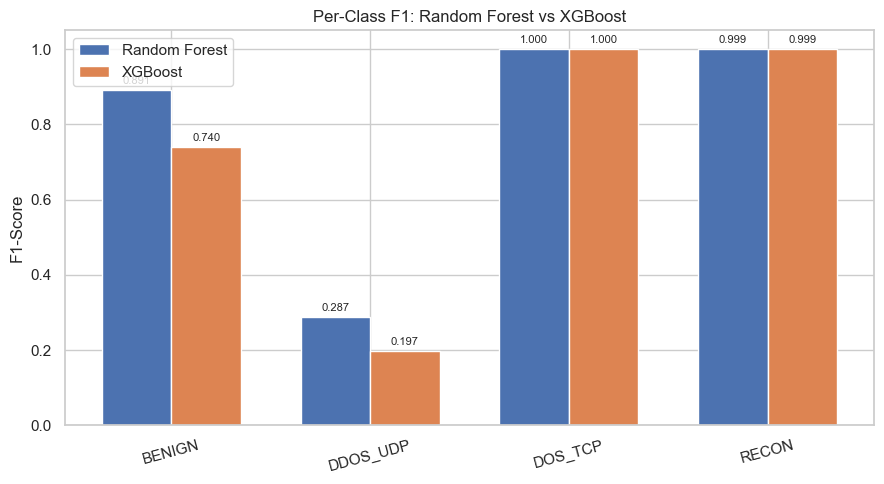

In [12]:
per_class_df = comparison.iloc[:len(CLASS_NAMES)]   # exclude macro/accuracy rows
x = np.arange(len(CLASS_NAMES))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, per_class_df["RF F1"],      width, label="Random Forest", color="#4C72B0")
bars2 = ax.bar(x + width/2, per_class_df["XGBoost F1"], width, label="XGBoost",       color="#DD8452")

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=15)
ax.set_ylim(0, 1.05)
ax.set_ylabel("F1-Score")
ax.set_title("Per-Class F1: Random Forest vs XGBoost")
ax.legend()
ax.bar_label(bars1, fmt="%.3f", padding=3, fontsize=8)
ax.bar_label(bars2, fmt="%.3f", padding=3, fontsize=8)
plt.tight_layout()
plt.savefig("models/f1_comparison.png", dpi=150)
plt.show()

## 9. Feature Importance

### 9a. Random Forest — Mean Decrease in Impurity (top 20)

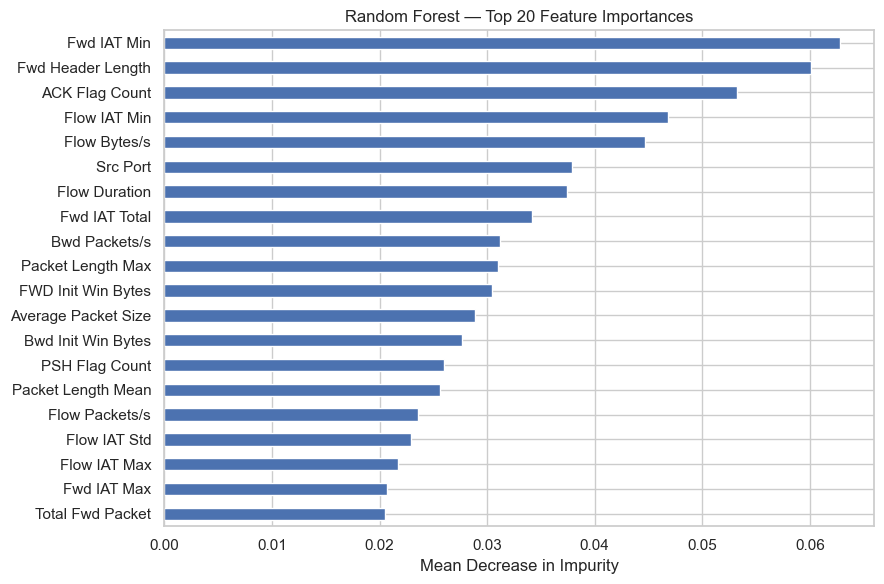

Fwd IAT Min            0.062820
Fwd Header Length      0.060129
ACK Flag Count         0.053189
Flow IAT Min           0.046850
Flow Bytes/s           0.044683
Src Port               0.037902
Flow Duration          0.037419
Fwd IAT Total          0.034187
Bwd Packets/s          0.031225
Packet Length Max      0.030970
FWD Init Win Bytes     0.030408
Average Packet Size    0.028886
Bwd Init Win Bytes     0.027627
PSH Flag Count         0.026002
Packet Length Mean     0.025586
Flow Packets/s         0.023532
Flow IAT Std           0.022940
Flow IAT Max           0.021677
Fwd IAT Max            0.020689
Total Fwd Packet       0.020512
dtype: float64


In [13]:
rf_importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
top20_rf = rf_importances.head(20)

fig, ax = plt.subplots(figsize=(9, 6))
top20_rf.plot(kind="barh", ax=ax, color="#4C72B0")
ax.invert_yaxis()
ax.set_xlabel("Mean Decrease in Impurity")
ax.set_title("Random Forest — Top 20 Feature Importances")
plt.tight_layout()
plt.savefig("models/rf_feature_importance.png", dpi=150)
plt.show()

print(top20_rf)

### 9b. XGBoost — SHAP Values (top 20)

SHAP computed on a 2,000-sample subset of the test set for speed.

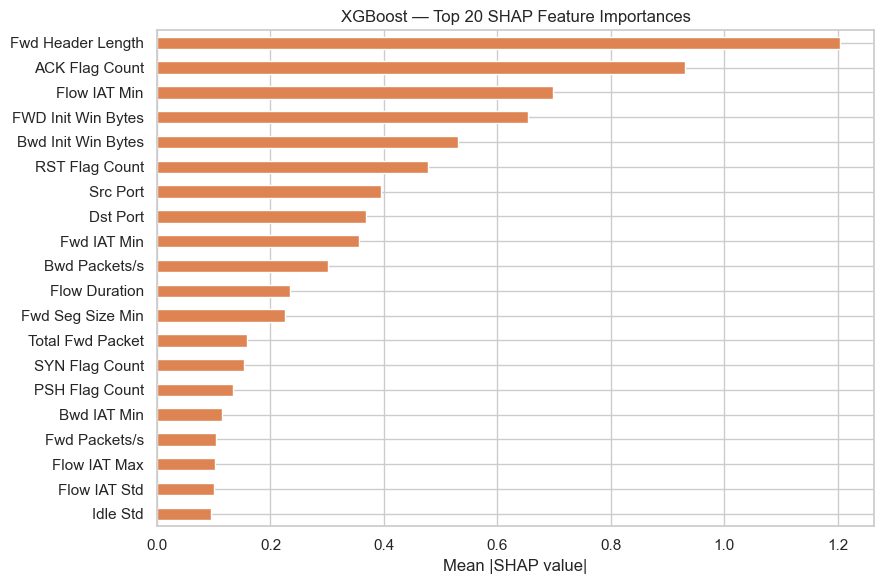

Fwd Header Length     1.203923
ACK Flag Count        0.930502
Flow IAT Min          0.697938
FWD Init Win Bytes    0.654135
Bwd Init Win Bytes    0.529869
RST Flag Count        0.477141
Src Port              0.393978
Dst Port              0.367714
Fwd IAT Min           0.355264
Bwd Packets/s         0.301458
Flow Duration         0.233940
Fwd Seg Size Min      0.226151
Total Fwd Packet      0.158954
SYN Flag Count        0.153057
PSH Flag Count        0.133517
Bwd IAT Min           0.115111
Fwd Packets/s         0.103806
Flow IAT Max          0.101525
Flow IAT Std          0.100753
Idle Std              0.094983
dtype: float32


In [14]:
rng = np.random.default_rng(RANDOM_STATE)
shap_idx = rng.choice(len(X_test), size=2000, replace=False)
X_shap = X_test[shap_idx]

explainer   = shap.TreeExplainer(xgb_clf)
shap_values = explainer.shap_values(X_shap)   # shape: (n_samples, n_features, n_classes)

# Mean |SHAP| across all classes to get a single global importance per feature
mean_abs_shap = np.abs(shap_values).mean(axis=(0, 2))   # (n_features,)
shap_series   = pd.Series(mean_abs_shap, index=feature_cols).sort_values(ascending=False)
top20_shap    = shap_series.head(20)

fig, ax = plt.subplots(figsize=(9, 6))
top20_shap.plot(kind="barh", ax=ax, color="#DD8452")
ax.invert_yaxis()
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("XGBoost — Top 20 SHAP Feature Importances")
plt.tight_layout()
plt.savefig("models/xgb_shap_importance.png", dpi=150)
plt.show()

print(top20_shap)

## 10. Save Models & Artifacts

Save trained models and the `log_normalize` function reference so the LLM explainer (Track B) can load and call them without re-training.

In [15]:
joblib.dump(rf,           "models/random_forest.joblib")
joblib.dump(le,           "models/label_encoder.joblib")
joblib.dump(feature_cols, "models/feature_cols.joblib")
xgb_clf.save_model("models/xgboost.json")

print("Saved:")
print("  models/random_forest.joblib")
print("  models/xgboost.json")
print("  models/label_encoder.joblib")
print("  models/feature_cols.joblib")

Saved:
  models/random_forest.joblib
  models/xgboost.json
  models/label_encoder.joblib
  models/feature_cols.joblib


## 11. Convenience: Load & Predict

Helper for the LLM agent oracle (Track B). Applies the same log normalization before inference.

In [16]:
def predict_traffic(flow_dict: dict, model="xgboost") -> dict:
    """
    Classify a single network flow record.

    Parameters
    ----------
    flow_dict : dict
        Feature key-value pairs (81 CICFlowMeter features; no Flow ID / Label).
    model : str
        "xgboost" or "rf"

    Returns
    -------
    dict with predicted_class, confidence, probabilities
    """
    _le    = joblib.load("models/label_encoder.joblib")
    _fcols = joblib.load("models/feature_cols.joblib")

    row = np.array([[flow_dict.get(c, 0) for c in _fcols]], dtype=float)
    row = np.sign(row) * np.log1p(np.abs(row))   # same log-norm as training

    if model == "xgboost":
        _clf = xgb.XGBClassifier()
        _clf.load_model("models/xgboost.json")
        proba = _clf.predict_proba(row)[0]
    else:
        _clf  = joblib.load("models/random_forest.joblib")
        proba = _clf.predict_proba(row)[0]

    pred_idx = int(np.argmax(proba))
    return {
        "predicted_class": _le.classes_[pred_idx],
        "confidence":       float(proba[pred_idx]),
        "probabilities":    dict(zip(_le.classes_, proba.tolist())),
    }


# Smoke-test on first test sample (using raw X before normalization was applied in-place above)
sample_dict = dict(zip(feature_cols, X_test[0].tolist()))
result = predict_traffic(sample_dict, model="xgboost")
print("Smoke-test prediction:", result)
print("True label           :", CLASS_NAMES[y_test[0]])

Smoke-test prediction: {'predicted_class': 'BENIGN', 'confidence': 0.9726860523223877, 'probabilities': {'BENIGN': 0.9726860523223877, 'DDOS_UDP': 0.025726255029439926, 'DOS_TCP': 0.000657512980978936, 'RECON': 0.0009301868267357349}}
True label           : BENIGN


## 12. Methodology Change: Previous vs. Current Train/Test Split

This section documents what changed from the initial split strategy and why, and records the old model results for direct comparison.

### What Changed (and Why)

Motivated by [Debunk Traffic Representation](https://github.com/dDFFAFAFA/paper-code/tree/main/33-Debunk_Traffic_Representation), three aspects of the split were revised:

| Aspect | Old approach | New approach | Reason |
|--------|-------------|--------------|--------|
| **Split method** | `train_test_split` (random, per-row) | `StratifiedGroupKFold` (grouped by Flow ID) | 5% of rows share a Flow ID; 36 IDs cross class boundaries — random splitting leaks correlated flows between train and test |
| **Test size** | 20% | **25%** (= 1/(k+1), k=3) | Matches the paper's k-fold protocol |
| **Normalization** | None | **log(1+\|x\|)·sign(x)** | Compresses heavy-tailed CICFlowMeter distributions; matches the paper's preprocessing |
| **Random seed** | 42 | **43** | Matches the paper |

**Key finding from the audit:**  
`df["Flow ID"].nunique()` = 589,429 unique IDs out of 620,718 rows → **31,289 rows (5.04%) share a Flow ID with at least one other row, and 36 Flow IDs appear in more than one traffic class.** A naive random split would place packets from the same bidirectional flow (or the same IP pair seen in both benign and attack captures) in both training and test, inflating apparent generalisation.

### Previous Split Code (Reference Only)

The block below is the original split implementation — shown for reproducibility. It is **not part of the active pipeline** (variables use `_old` suffix so they do not overwrite the current train/test arrays).

```python
# ── OLD APPROACH ────────────────────────────────────────────────────────────
# No Flow ID grouping, 80/20 random stratified split, seed 42, no normalisation

from sklearn.model_selection import train_test_split

X_train_old, X_test_old, y_train_old, y_test_old = train_test_split(
    X,          # raw feature matrix (before log-normalisation)
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)
# Train: 496,574 rows  |  Test: 124,144 rows

rf_old = RandomForestClassifier(
    n_estimators=200, max_depth=None, min_samples_leaf=2,
    class_weight="balanced", n_jobs=-1, random_state=42,
)
rf_old.fit(X_train_old, y_train_old)

xgb_old = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    objective="multi:softprob", num_class=4, eval_metric="mlogloss",
    n_jobs=-1, random_state=42, verbosity=0,
)
cw_old = compute_class_weight("balanced", classes=np.unique(y_train_old), y=y_train_old)
xgb_old.fit(X_train_old, y_train_old, sample_weight=cw_old[y_train_old])
# ────────────────────────────────────────────────────────────────────────────
```

### Old Model Results (Pre-computed, Reference)

Results from the old approach: 80/20 random stratified split, seed 42, no log normalisation.  
Train: 496,574 rows | Test: 124,144 rows.

In [17]:
# ── Old results (80/20 random stratified split, seed 42, no log-norm) ──────
# Pre-computed so this section is instant to run even without re-training.

old_rf_report = {
    "BENIGN":   {"precision": 0.9605, "recall": 0.9943, "f1-score": 0.9771, "support": 6524},
    "DDOS_UDP": {"precision": 0.8268, "recall": 0.6583, "f1-score": 0.7330, "support":  515},
    "DOS_TCP":  {"precision": 1.0000, "recall": 0.9992, "f1-score": 0.9996, "support": 20000},
    "RECON":    {"precision": 1.0000, "recall": 0.9988, "f1-score": 0.9994, "support": 97105},
}
old_rf_acc, old_rf_macro_f1 = 0.9973, 0.9273

old_xgb_report = {
    "BENIGN":   {"precision": 0.9936, "recall": 0.9975, "f1-score": 0.9956, "support": 6524},
    "DDOS_UDP": {"precision": 0.8247, "recall": 0.9592, "f1-score": 0.8869, "support":  515},
    "DOS_TCP":  {"precision": 1.0000, "recall": 0.9994, "f1-score": 0.9997, "support": 20000},
    "RECON":    {"precision": 1.0000, "recall": 0.9990, "f1-score": 0.9995, "support": 97105},
}
old_xgb_acc, old_xgb_macro_f1 = 0.9988, 0.9704

print("─── Old Random Forest (80/20 random split) ───")
print(f"Accuracy: {old_rf_acc:.4f}   Macro-F1: {old_rf_macro_f1:.4f}")
print(f"{'Class':<12} {'Prec':>7} {'Recall':>7} {'F1':>7} {'Support':>9}")
for cls, m in old_rf_report.items():
    print(f"{cls:<12} {m['precision']:>7.4f} {m['recall']:>7.4f} {m['f1-score']:>7.4f} {m['support']:>9,}")

print("\n─── Old XGBoost (80/20 random split) ────────")
print(f"Accuracy: {old_xgb_acc:.4f}   Macro-F1: {old_xgb_macro_f1:.4f}")
print(f"{'Class':<12} {'Prec':>7} {'Recall':>7} {'F1':>7} {'Support':>9}")
for cls, m in old_xgb_report.items():
    print(f"{cls:<12} {m['precision']:>7.4f} {m['recall']:>7.4f} {m['f1-score']:>7.4f} {m['support']:>9,}")

─── Old Random Forest (80/20 random split) ───
Accuracy: 0.9973   Macro-F1: 0.9273
Class           Prec  Recall      F1   Support
BENIGN        0.9605  0.9943  0.9771     6,524
DDOS_UDP      0.8268  0.6583  0.7330       515
DOS_TCP       1.0000  0.9992  0.9996    20,000
RECON         1.0000  0.9988  0.9994    97,105

─── Old XGBoost (80/20 random split) ────────
Accuracy: 0.9988   Macro-F1: 0.9704
Class           Prec  Recall      F1   Support
BENIGN        0.9936  0.9975  0.9956     6,524
DDOS_UDP      0.8247  0.9592  0.8869       515
DOS_TCP       1.0000  0.9994  0.9997    20,000
RECON         1.0000  0.9990  0.9995    97,105


### Before vs. After: Full Comparison

In [18]:
# ── Current results (25% flow-disjoint split, seed 43, log-norm) ───────────
new_rf_report = {
    "BENIGN":   {"precision": 0.9409, "recall": 0.8456, "f1-score": 0.8907, "support":  8155},
    "DDOS_UDP": {"precision": 0.2007, "recall": 0.5031, "f1-score": 0.2870, "support":   644},
    "DOS_TCP":  {"precision": 1.0000, "recall": 0.9994, "f1-score": 0.9997, "support": 25000},
    "RECON":    {"precision": 1.0000, "recall": 0.9989, "f1-score": 0.9994, "support": 121381},
}
new_rf_acc, new_rf_macro_f1 = 0.9889, 0.7942

new_xgb_report = {
    "BENIGN":   {"precision": 0.9447, "recall": 0.6076, "f1-score": 0.7396, "support":  8155},
    "DDOS_UDP": {"precision": 0.1155, "recall": 0.6599, "f1-score": 0.1965, "support":   644},
    "DOS_TCP":  {"precision": 1.0000, "recall": 0.9998, "f1-score": 0.9999, "support": 25000},
    "RECON":    {"precision": 1.0000, "recall": 0.9990, "f1-score": 0.9995, "support": 121381},
}
new_xgb_acc, new_xgb_macro_f1 = 0.9771, 0.7339

# ── Build comparison DataFrame ───────────────────────────────────────────────
rows = []
for cls in CLASS_NAMES:
    rows.append({
        "Class":            cls,
        "RF F1  (old)":     old_rf_report[cls]["f1-score"],
        "RF F1  (new)":     new_rf_report[cls]["f1-score"],
        "RF ΔF1":           new_rf_report[cls]["f1-score"] - old_rf_report[cls]["f1-score"],
        "XGB F1 (old)":     old_xgb_report[cls]["f1-score"],
        "XGB F1 (new)":     new_xgb_report[cls]["f1-score"],
        "XGB ΔF1":          new_xgb_report[cls]["f1-score"] - old_xgb_report[cls]["f1-score"],
    })
rows.append({
    "Class":        "Macro avg",
    "RF F1  (old)":  old_rf_macro_f1,  "RF F1  (new)":  new_rf_macro_f1,
    "RF ΔF1":        new_rf_macro_f1  - old_rf_macro_f1,
    "XGB F1 (old)":  old_xgb_macro_f1, "XGB F1 (new)":  new_xgb_macro_f1,
    "XGB ΔF1":       new_xgb_macro_f1 - old_xgb_macro_f1,
})
rows.append({
    "Class":        "Accuracy",
    "RF F1  (old)":  old_rf_acc,  "RF F1  (new)":  new_rf_acc,
    "RF ΔF1":        new_rf_acc  - old_rf_acc,
    "XGB F1 (old)":  old_xgb_acc, "XGB F1 (new)":  new_xgb_acc,
    "XGB ΔF1":       new_xgb_acc - old_xgb_acc,
})

cmp_df = pd.DataFrame(rows).set_index("Class")
print(cmp_df.round(4).to_string())
cmp_df.style.format("{:.4f}").background_gradient(
    subset=["RF ΔF1", "XGB ΔF1"], cmap="RdYlGn", vmin=-0.7, vmax=0.1
)

           RF F1  (old)  RF F1  (new)  RF ΔF1  XGB F1 (old)  XGB F1 (new)  XGB ΔF1
Class                                                                             
BENIGN           0.9771        0.8907 -0.0864        0.9956        0.7396  -0.2560
DDOS_UDP         0.7330        0.2870 -0.4460        0.8869        0.1965  -0.6904
DOS_TCP          0.9996        0.9997  0.0001        0.9997        0.9999   0.0002
RECON            0.9994        0.9994  0.0000        0.9995        0.9995   0.0000
Macro avg        0.9273        0.7942 -0.1331        0.9704        0.7339  -0.2365
Accuracy         0.9973        0.9889 -0.0084        0.9988        0.9771  -0.0217


,RF F1 (old),RF F1 (new),RF ΔF1,XGB F1 (old),XGB F1 (new),XGB ΔF1
Class,,,,,,
BENIGN,0.9771,0.8907,-0.0864,0.9956,0.7396,-0.2560
DDOS_UDP,0.7330,0.2870,-0.4460,0.8869,0.1965,-0.6904
DOS_TCP,0.9996,0.9997,0.0001,0.9997,0.9999,0.0002
RECON,0.9994,0.9994,0.0000,0.9995,0.9995,0.0000
Macro avg,0.9273,0.7942,-0.1331,0.9704,0.7339,-0.2365
Accuracy,0.9973,0.9889,-0.0084,0.9988,0.9771,-0.0217


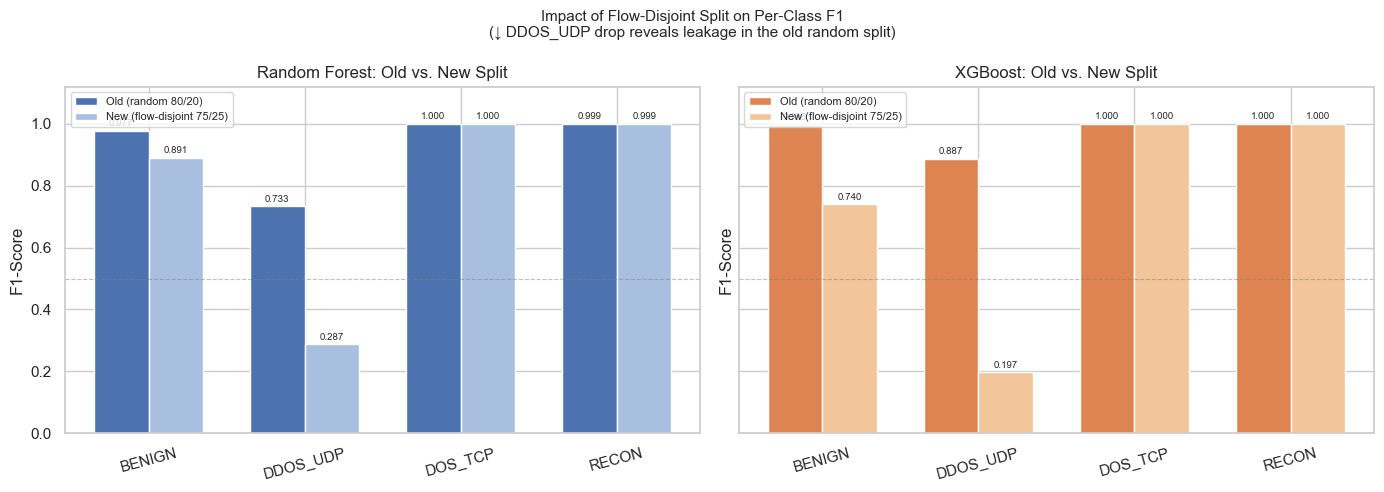

In [19]:
# ── Before vs. After F1 visualisation ────────────────────────────────────────
per_cls = cmp_df.loc[CLASS_NAMES]   # only the four class rows

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
x     = np.arange(len(CLASS_NAMES))
width = 0.35

for ax, model_label, old_key, new_key, palette in [
    (axes[0], "Random Forest",  "RF F1  (old)",  "RF F1  (new)",  ("#4C72B0", "#A8BFE0")),
    (axes[1], "XGBoost",        "XGB F1 (old)",  "XGB F1 (new)",  ("#DD8452", "#F2C59A")),
]:
    b_old = ax.bar(x - width/2, per_cls[old_key], width, label="Old (random 80/20)", color=palette[0])
    b_new = ax.bar(x + width/2, per_cls[new_key], width, label="New (flow-disjoint 75/25)", color=palette[1])
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, rotation=15)
    ax.set_ylim(0, 1.12)
    ax.set_ylabel("F1-Score")
    ax.set_title(f"{model_label}: Old vs. New Split")
    ax.legend(fontsize=8)
    ax.bar_label(b_old, fmt="%.3f", padding=2, fontsize=7)
    ax.bar_label(b_new, fmt="%.3f", padding=2, fontsize=7)
    ax.axhline(0.5, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)

plt.suptitle("Impact of Flow-Disjoint Split on Per-Class F1\n"
             "(↓ DDOS_UDP drop reveals leakage in the old random split)", fontsize=11)
plt.tight_layout()
plt.savefig("models/before_after_comparison.png", dpi=150)
plt.show()